# NexaTel Customer Churn Analytics

## Phase 2 — Exploratory Data Analysis (EDA)

### Objective

The objective of this phase is to explore customer churn patterns and identify
relationships between churn and important customer, service, geographic,
network, and retention variables.

The analysis covers:

1. Overall Churn Rate
2. Churn by Billing Cycle
3. Churn by Tenure Band
4. Churn by Unresolved Complaints
5. Churn by Customer Segment
6. Top 10 States / Circles by Churned Customers
7. Average Data Usage by City Tier
8. ARPU Distribution
9. Network Quality vs Churn
10. Retention Campaign Outcomes

Each analysis includes a visualization and business-oriented observations.
All charts are exported as PNG images for documentation and submission.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Chart settings
sns.set_theme(style="whitegrid")

# Create output folder
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"Chart output folder: {CHART_DIR.resolve()}")

Libraries imported successfully.
Chart output folder: C:\Users\ASUS\Desktop\Internmo\Project - 2\charts


In [3]:
# ============================================================
# SET DATA FOLDER PATH HERE
# ============================================================

DATA_DIR = Path(r"C:\Users\ASUS\Desktop\Internmo\Project - 2")

# Check whether the folder exists
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR}\n"
        "Please update DATA_DIR with the correct folder path."
    )

print("Data folder found:")
print(DATA_DIR)

Data folder found:
C:\Users\ASUS\Desktop\Internmo\Project - 2


### Verify the CSV Files

In [5]:
# Find all CSV files in the data folder
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}")
print()

for file in csv_files:
    print(file.name)

CSV files found: 24

billing.csv
cities.csv
complaints.csv
contracts.csv
customer_feedback.csv
customers.csv
data_quality_issue_log.csv
devices.csv
employees.csv
marketing_campaigns.csv
network_quality.csv
payments.csv
plan_history.csv
plans.csv
recharges.csv
regions.csv
retention_campaigns.csv
states.csv
stores.csv
subscriptions.csv
support_tickets.csv
usage_data.csv
usage_sms.csv
usage_voice.csv


### Verify 24 Files

In [7]:
EXPECTED_FILES = {
    "customers.csv",
    "subscriptions.csv",
    "plans.csv",
    "plan_history.csv",
    "contracts.csv",
    "devices.csv",
    "billing.csv",
    "payments.csv",
    "recharges.csv",
    "usage_voice.csv",
    "usage_sms.csv",
    "usage_data.csv",
    "network_quality.csv",
    "support_tickets.csv",
    "complaints.csv",
    "customer_feedback.csv",
    "retention_campaigns.csv",
    "marketing_campaigns.csv",
    "employees.csv",
    "stores.csv",
    "regions.csv",
    "cities.csv",
    "states.csv",
    "data_quality_issue_log.csv"
}

FOUND_FILES = {file.name for file in csv_files}

missing_files = EXPECTED_FILES - FOUND_FILES
extra_files = FOUND_FILES - EXPECTED_FILES

print("Expected files :", len(EXPECTED_FILES))
print("Found files    :", len(FOUND_FILES))
print()

if missing_files:
    print("Missing files:")
    for file in sorted(missing_files):
        print(" -", file)
else:
    print("All 24 required CSV files are present.")

if extra_files:
    print("\nAdditional CSV files:")
    for file in sorted(extra_files):
        print(" -", file)

Expected files : 24
Found files    : 24

All 24 required CSV files are present.


### Load All 24 CSV Files

In [9]:
# Dictionary to store all datasets
dfs = {}

for file in csv_files:
    table_name = file.stem
    
    try:
        df = pd.read_csv(file)
        dfs[table_name] = df
        print(f"Loaded: {table_name:<25} {df.shape}")
        
    except Exception as e:
        print(f"ERROR loading {file.name}: {e}")

print("\nTotal tables loaded:", len(dfs))

Loaded: billing                   (115313, 9)
Loaded: cities                    (68, 8)
Loaded: complaints                (16584, 7)
Loaded: contracts                 (10607, 9)
Loaded: customer_feedback         (28499, 7)
Loaded: customers                 (19076, 25)
Loaded: data_quality_issue_log    (20, 3)
Loaded: devices                   (19000, 8)
Loaded: employees                 (800, 9)
Loaded: marketing_campaigns       (40, 9)
Loaded: network_quality           (57000, 8)
Loaded: payments                  (92362, 7)
Loaded: plan_history              (19349, 6)
Loaded: plans                     (25, 10)
Loaded: recharges                 (146501, 6)
Loaded: regions                   (4, 3)
Loaded: retention_campaigns       (6475, 8)
Loaded: states                    (36, 4)
Loaded: stores                    (2180, 7)
Loaded: subscriptions             (20523, 8)
Loaded: support_tickets           (31490, 11)
Loaded: usage_data                (57000, 5)
Loaded: usage_sms           

### Verify Phase 1 data

In [10]:
# Verify that Phase 1 data dictionary exists

if "dfs" not in globals():
    raise NameError(
        "The 'dfs' dictionary was not found. "
        "Run your Phase 1 data-loading cells first."
    )

required_tables = [
    "customers",
    "plans",
    "complaints",
    "usage_data",
    "network_quality",
    "retention_campaigns",
    "states",
    "regions"
]

missing_tables = [table for table in required_tables if table not in dfs]

if missing_tables:
    raise KeyError(
        f"Required tables are missing from dfs: {missing_tables}"
    )

print("Phase 1 data verified successfully.")
print("Available tables:", len(dfs))

Phase 1 data verified successfully.
Available tables: 24


### Create copies of the required tables

In [11]:
customers = dfs["customers"].copy()
plans = dfs["plans"].copy()
complaints = dfs["complaints"].copy()
usage_data = dfs["usage_data"].copy()
network_quality = dfs["network_quality"].copy()
retention_campaigns = dfs["retention_campaigns"].copy()
states = dfs["states"].copy()
regions = dfs["regions"].copy()

### Standardize column names

In [12]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


customers = clean_column_names(customers)
plans = clean_column_names(plans)
complaints = clean_column_names(complaints)
usage_data = clean_column_names(usage_data)
network_quality = clean_column_names(network_quality)
retention_campaigns = clean_column_names(retention_campaigns)
states = clean_column_names(states)
regions = clean_column_names(regions)

print("Column names standardized.")

Column names standardized.


### Validate important columns

In [13]:
required_columns = {
    "customers": [
        "customer_id",
        "customer_segment",
        "tenure_months",
        "customer_status",
        "city_tier",
        "plan_id",
        "state_id",
        "region_id"
    ],
    "plans": [
        "plan_id",
        "billing_cycle",
        "monthly_charge"
    ],
    "complaints": [
        "customer_id",
        "status"
    ],
    "usage_data": [
        "customer_id",
        "data_gb_used"
    ],
    "network_quality": [
        "customer_id",
        "dropped_call_rate_pct"
    ],
    "retention_campaigns": [
        "customer_id",
        "response",
        "retained_flag"
    ]
}

for table_name, columns in required_columns.items():
    table = {
        "customers": customers,
        "plans": plans,
        "complaints": complaints,
        "usage_data": usage_data,
        "network_quality": network_quality,
        "retention_campaigns": retention_campaigns
    }[table_name]

    missing = [col for col in columns if col not in table.columns]

    if missing:
        raise KeyError(
            f"{table_name} is missing required columns: {missing}"
        )

print("All required columns are available.")

All required columns are available.


### The master customer analysis table

In [14]:
# Start with one row per customer
eda = customers.copy()

# --------------------------------------------------
# 1. Churn flag
# --------------------------------------------------

eda["churn_flag"] = (
    eda["customer_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("churned")
    .astype(int)
)

# --------------------------------------------------
# 2. Clean numeric columns
# --------------------------------------------------

eda["tenure_months"] = pd.to_numeric(
    eda["tenure_months"],
    errors="coerce"
)

# --------------------------------------------------
# 3. Clean plan table
# --------------------------------------------------

plans["monthly_charge"] = pd.to_numeric(
    plans["monthly_charge"],
    errors="coerce"
)

# Add billing cycle and monthly charge
plan_info = plans[
    ["plan_id", "billing_cycle", "monthly_charge"]
].drop_duplicates("plan_id")

eda = eda.merge(
    plan_info,
    on="plan_id",
    how="left"
)

# --------------------------------------------------
# 4. State information
# --------------------------------------------------

if "state_name" in states.columns:
    state_info = states[
        ["state_id", "state_name"]
    ].drop_duplicates("state_id")

    eda = eda.merge(
        state_info,
        on="state_id",
        how="left"
    )
else:
    eda["state_name"] = eda["state_id"]

# --------------------------------------------------
# 5. Region / circle information
# --------------------------------------------------

if "region_name" in regions.columns:
    region_info = regions[
        ["region_id", "region_name"]
    ].drop_duplicates("region_id")

    eda = eda.merge(
        region_info,
        on="region_id",
        how="left"
    )
else:
    eda["region_name"] = eda["region_id"]

# --------------------------------------------------
# 6. Unresolved complaints per customer
# --------------------------------------------------

complaints["status_clean"] = (
    complaints["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

unresolved = (
    complaints[
        complaints["status_clean"] == "unresolved"
    ]
    .groupby("customer_id")
    .size()
    .rename("unresolved_complaints")
)

eda = eda.merge(
    unresolved,
    on="customer_id",
    how="left"
)

eda["unresolved_complaints"] = (
    eda["unresolved_complaints"]
    .fillna(0)
    .astype(int)
)

# --------------------------------------------------
# 7. Average data usage per customer
# --------------------------------------------------

usage_customer = (
    usage_data
    .groupby("customer_id", as_index=False)["data_gb_used"]
    .mean()
    .rename(columns={
        "data_gb_used": "avg_data_gb"
    })
)

eda = eda.merge(
    usage_customer,
    on="customer_id",
    how="left"
)

# --------------------------------------------------
# 8. Average dropped-call rate per customer
# --------------------------------------------------

network_customer = (
    network_quality
    .groupby("customer_id", as_index=False)[
        "dropped_call_rate_pct"
    ]
    .mean()
    .rename(columns={
        "dropped_call_rate_pct": "avg_dropped_call_rate"
    })
)

eda = eda.merge(
    network_customer,
    on="customer_id",
    how="left"
)

# --------------------------------------------------
# Final check
# --------------------------------------------------

print("EDA master table created successfully.")
print("Rows:", len(eda))
print("Columns:", len(eda.columns))
print("Unique customers:", eda["customer_id"].nunique())

EDA master table created successfully.
Rows: 19076
Columns: 33
Unique customers: 19000


### Create tenure bands

In [15]:
def create_tenure_band(months):
    if pd.isna(months):
        return "Unknown"
    elif months < 3:
        return "0-3m"
    elif months < 12:
        return "3-12m"
    elif months < 36:
        return "1-3y"
    else:
        return "3y+"

eda["tenure_band"] = eda["tenure_months"].apply(
    create_tenure_band
)

tenure_order = [
    "0-3m",
    "3-12m",
    "1-3y",
    "3y+",
    "Unknown"
]

eda["tenure_band"] = pd.Categorical(
    eda["tenure_band"],
    categories=tenure_order,
    ordered=True
)

eda["tenure_band"].value_counts().sort_index()

tenure_band
0-3m         563
3-12m       1486
1-3y        2905
3y+        14122
Unknown        0
Name: count, dtype: int64

### Overall Churn Rate

In [16]:
# Customer counts
status_counts = (
    eda["customer_status"]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
)

total_customers = len(eda)
churned_customers = int(eda["churn_flag"].sum())
active_customers = total_customers - churned_customers

churn_rate = (
    churned_customers / total_customers * 100
)

print(f"Total Customers : {total_customers:,}")
print(f"Active Customers: {active_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers : 19,076
Active Customers: 15,560
Churned Customers: 3,516
Overall Churn Rate: 18.43%


### Chart 1

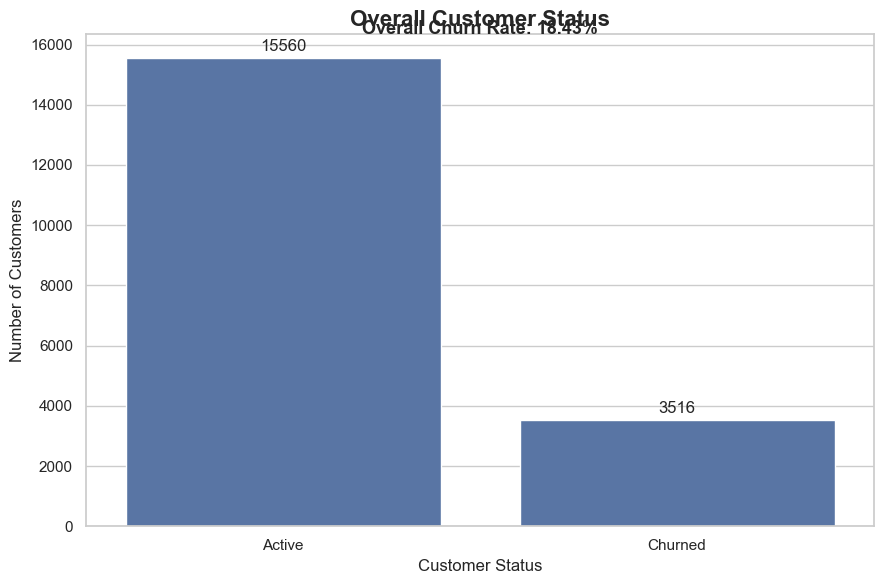

In [17]:
plot_data = pd.DataFrame({
    "Status": ["Active", "Churned"],
    "Customers": [
        active_customers,
        churned_customers
    ]
})

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=plot_data,
    x="Status",
    y="Customers",
    ax=ax
)

ax.set_title(
    "Overall Customer Status",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

ax.text(
    0.5,
    max(plot_data["Customers"]) * 1.05,
    f"Overall Churn Rate: {churn_rate:.2f}%",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "01_overall_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Automatic observation

In [18]:
print(
    f"Observation: The overall customer churn rate is "
    f"{churn_rate:.2f}%, with {churned_customers:,} churned "
    f"customers out of {total_customers:,} total customers."
)

print(
    f"The remaining {active_customers:,} customers are active, "
    f"representing {(active_customers / total_customers) * 100:.2f}% "
    f"of the customer base."
)

Observation: The overall customer churn rate is 18.43%, with 3,516 churned customers out of 19,076 total customers.
The remaining 15,560 customers are active, representing 81.57% of the customer base.


### Churn by Billing Cycle

In [19]:
billing_summary = (
    eda.dropna(subset=["billing_cycle"])
    .groupby("billing_cycle", observed=True)
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
    .reset_index()
)

billing_summary["churn_rate"] = (
    billing_summary["churned_customers"]
    / billing_summary["total_customers"]
    * 100
)

billing_summary

,billing_cycle,total_customers,churned_customers,churn_rate
0,Annual,5051,364,7.21
1,Monthly,13949,3152,22.60


### Chart 2

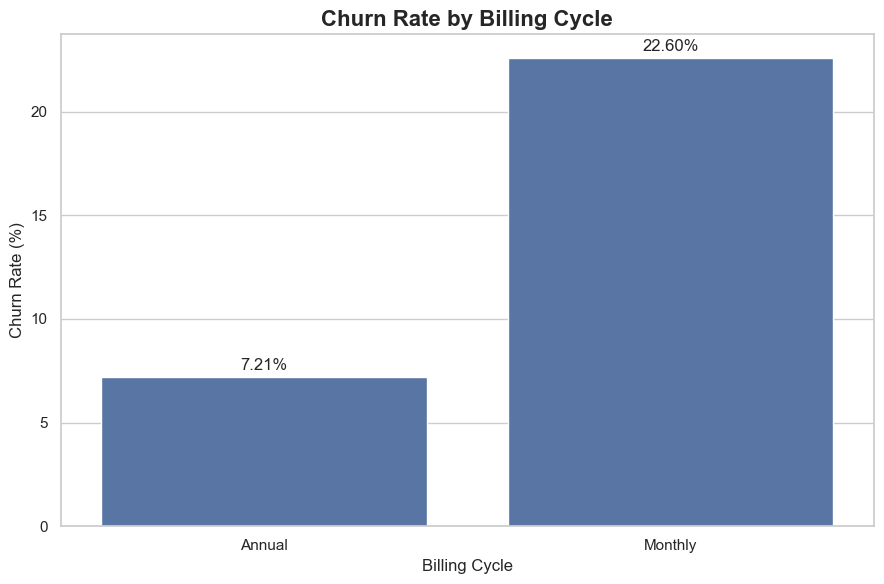

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=billing_summary,
    x="billing_cycle",
    y="churn_rate",
    ax=ax
)

ax.set_title(
    "Churn Rate by Billing Cycle",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Billing Cycle")
ax.set_ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "02_churn_by_billing_cycle.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Automatic observation

In [21]:
highest_billing = billing_summary.loc[
    billing_summary["churn_rate"].idxmax()
]

lowest_billing = billing_summary.loc[
    billing_summary["churn_rate"].idxmin()
]

print(
    f"Observation: The {highest_billing['billing_cycle']} billing "
    f"cycle has the higher churn rate at "
    f"{highest_billing['churn_rate']:.2f}%."
)

print(
    f"The {lowest_billing['billing_cycle']} billing cycle has a "
    f"churn rate of {lowest_billing['churn_rate']:.2f}%. "
    f"This indicates a difference in churn behaviour between "
    f"billing-cycle groups."
)

Observation: The Monthly billing cycle has the higher churn rate at 22.60%.
The Annual billing cycle has a churn rate of 7.21%. This indicates a difference in churn behaviour between billing-cycle groups.


### Churn by Tenure Band

In [22]:
tenure_summary = (
    eda[eda["tenure_band"] != "Unknown"]
    .groupby("tenure_band", observed=True)
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
    .reset_index()
)

tenure_summary["churn_rate"] = (
    tenure_summary["churned_customers"]
    / tenure_summary["total_customers"]
    * 100
)

tenure_summary

,tenure_band,total_customers,churned_customers,churn_rate
0,0-3m,562,444,79.00
1,3-12m,1479,808,54.63
2,1-3y,2898,1071,36.96
3,3y+,14061,1193,8.48


### Chart 3

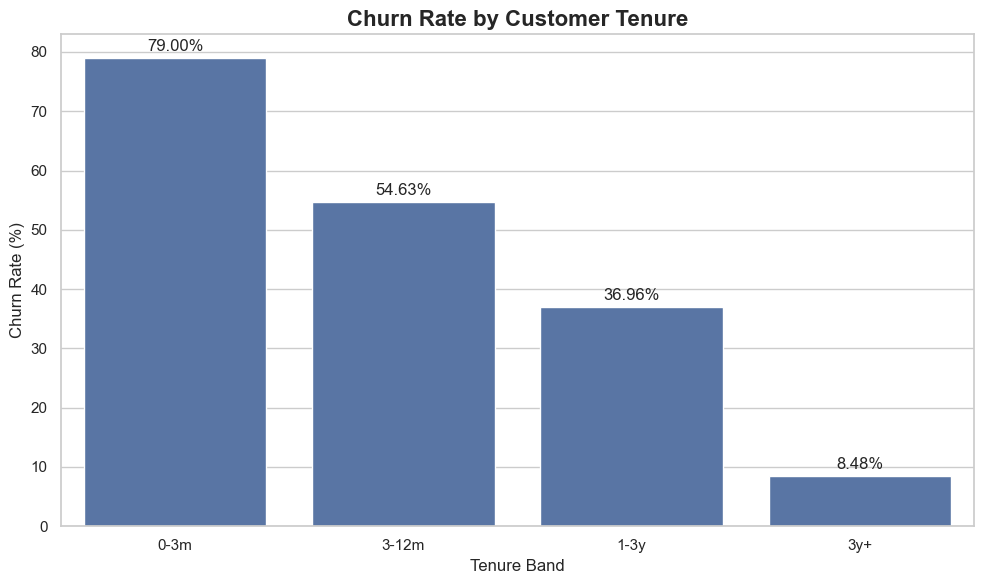

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tenure_summary,
    x="tenure_band",
    y="churn_rate",
    order=["0-3m", "3-12m", "1-3y", "3y+"],
    ax=ax
)

ax.set_title(
    "Churn Rate by Customer Tenure",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Tenure Band")
ax.set_ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "03_churn_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

In [24]:
highest_tenure = tenure_summary.loc[
    tenure_summary["churn_rate"].idxmax()
]

lowest_tenure = tenure_summary.loc[
    tenure_summary["churn_rate"].idxmin()
]

print(
    f"Observation: The {highest_tenure['tenure_band']} tenure band "
    f"has the highest churn rate at "
    f"{highest_tenure['churn_rate']:.2f}%."
)

print(
    f"The {lowest_tenure['tenure_band']} group has the lowest churn "
    f"rate at {lowest_tenure['churn_rate']:.2f}%. "
    f"This highlights how churn varies across different stages "
    f"of the customer lifecycle."
)

Observation: The 0-3m tenure band has the highest churn rate at 79.00%.
The 3y+ group has the lowest churn rate at 8.48%. This highlights how churn varies across different stages of the customer lifecycle.


### Churn by Number of Unresolved Complaints

In [25]:
def complaint_band(count):
    if count == 0:
        return "0"
    elif count == 1:
        return "1"
    elif count == 2:
        return "2"
    else:
        return "3+"

eda["unresolved_complaint_band"] = (
    eda["unresolved_complaints"]
    .apply(complaint_band)
)

complaint_order = [
    "0",
    "1",
    "2",
    "3+"
]

complaint_summary = (
    eda.groupby(
        "unresolved_complaint_band",
        observed=True
    )
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
    .reset_index()
)

complaint_summary["churn_rate"] = (
    complaint_summary["churned_customers"]
    / complaint_summary["total_customers"]
    * 100
)

complaint_summary["unresolved_complaint_band"] = pd.Categorical(
    complaint_summary["unresolved_complaint_band"],
    categories=complaint_order,
    ordered=True
)

complaint_summary = complaint_summary.sort_values(
    "unresolved_complaint_band"
)

complaint_summary

,unresolved_complaint_band,total_customers,churned_customers,churn_rate
0,0,12942,1962,15.16
1,1,4934,1156,23.43
2,2,975,325,33.33
3,3+,149,73,48.99


### Chart 4

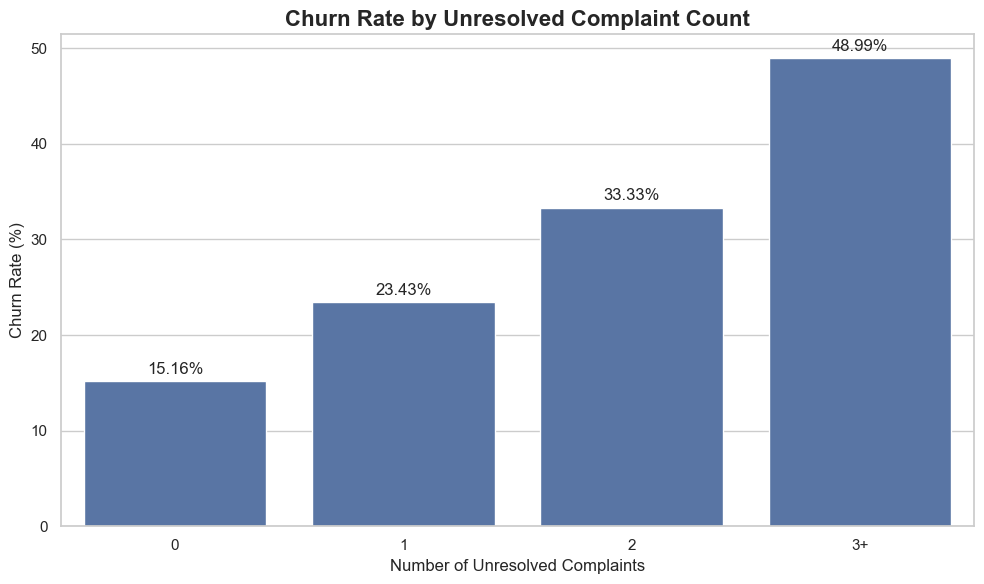

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=complaint_summary,
    x="unresolved_complaint_band",
    y="churn_rate",
    order=complaint_order,
    ax=ax
)

ax.set_title(
    "Churn Rate by Unresolved Complaint Count",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of Unresolved Complaints")
ax.set_ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "04_churn_by_unresolved_complaints.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Automatic observation

In [28]:
zero_complaints = complaint_summary[
    complaint_summary["unresolved_complaint_band"] == "0"
]["churn_rate"].iloc[0]

three_plus = complaint_summary[
    complaint_summary["unresolved_complaint_band"] == "3+"
]["churn_rate"].iloc[0]

print(
    f"Observation: Customers with no unresolved complaints have "
    f"a churn rate of {zero_complaints:.2f}%, while customers with "
    f"3 or more unresolved complaints have a churn rate of "
    f"{three_plus:.2f}%."
)

if three_plus > zero_complaints:
    print(
        "The analysis shows a higher churn rate among customers "
        "with multiple unresolved complaints, indicating a "
        "potential relationship between unresolved service issues "
        "and customer churn."
    )
else:
    print(
        "The analysis does not show a higher churn rate among "
        "customers with 3+ unresolved complaints compared with "
        "customers with no unresolved complaints."
    )

Observation: Customers with no unresolved complaints have a churn rate of 15.16%, while customers with 3 or more unresolved complaints have a churn rate of 48.99%.
The analysis shows a higher churn rate among customers with multiple unresolved complaints, indicating a potential relationship between unresolved service issues and customer churn.


### Churn by Customer Segment

In [29]:
segment_summary = (
    eda.groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
    .reset_index()
)

segment_summary["churn_rate"] = (
    segment_summary["churned_customers"]
    / segment_summary["total_customers"]
    * 100
)

segment_summary

,customer_segment,total_customers,churned_customers,churn_rate
0,Enterprise,1390,166,11.94
1,Mass,2932,787,26.84
2,Premium,8482,1286,15.16
3,Value,6196,1277,20.61


### Chart 5

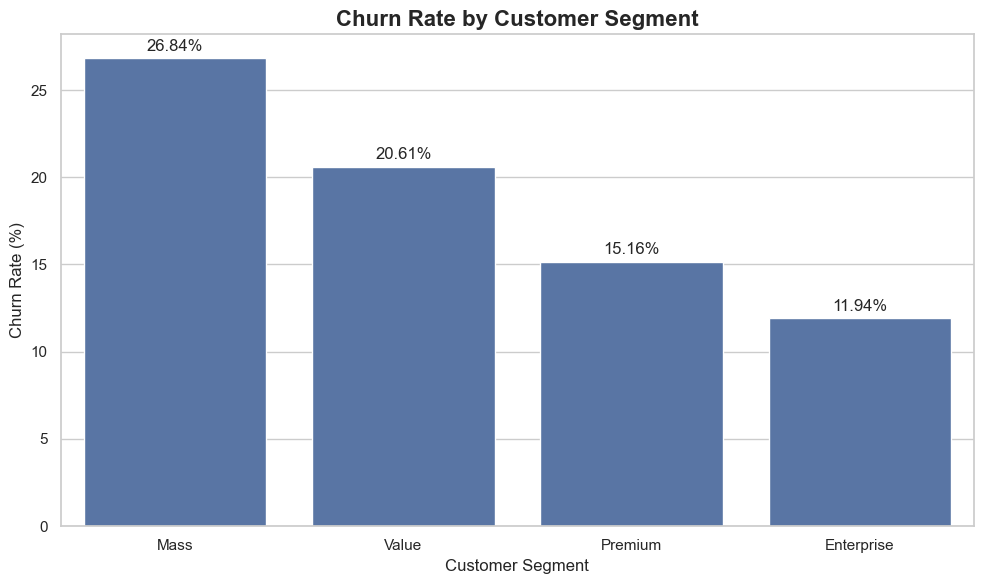

In [30]:
segment_order = [
    "Mass",
    "Value",
    "Premium",
    "Enterprise"
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="customer_segment",
    y="churn_rate",
    order=segment_order,
    ax=ax
)

ax.set_title(
    "Churn Rate by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Customer Segment")
ax.set_ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "05_churn_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

In [31]:
highest_segment = segment_summary.loc[
    segment_summary["churn_rate"].idxmax()
]

lowest_segment = segment_summary.loc[
    segment_summary["churn_rate"].idxmin()
]

print(
    f"Observation: The {highest_segment['customer_segment']} "
    f"segment has the highest churn rate at "
    f"{highest_segment['churn_rate']:.2f}%."
)

print(
    f"The {lowest_segment['customer_segment']} segment has the "
    f"lowest churn rate at {lowest_segment['churn_rate']:.2f}%. "
    f"This shows that churn behaviour differs across customer "
    f"segments."
)

Observation: The Mass segment has the highest churn rate at 26.84%.
The Enterprise segment has the lowest churn rate at 11.94%. This shows that churn behaviour differs across customer segments.


### Top 10 States / Circles by Churned Customers

In [32]:
#State Chart 
state_churn = (
    eda[eda["churn_flag"] == 1]
    .groupby("state_name")["customer_id"]
    .nunique()
    .reset_index(name="churned_customers")
    .sort_values(
        "churned_customers",
        ascending=False
    )
    .head(10)
)

state_churn

,state_name,churned_customers
15,Maharashtra,305
26,Uttar Pradesh,285
23,Tamil Nadu,280
21,Rajasthan,244
12,Karnataka,222
7,Gujarat,191
14,Madhya Pradesh,182
13,Kerala,162
0,Andhra Pradesh,160
28,West Bengal,157


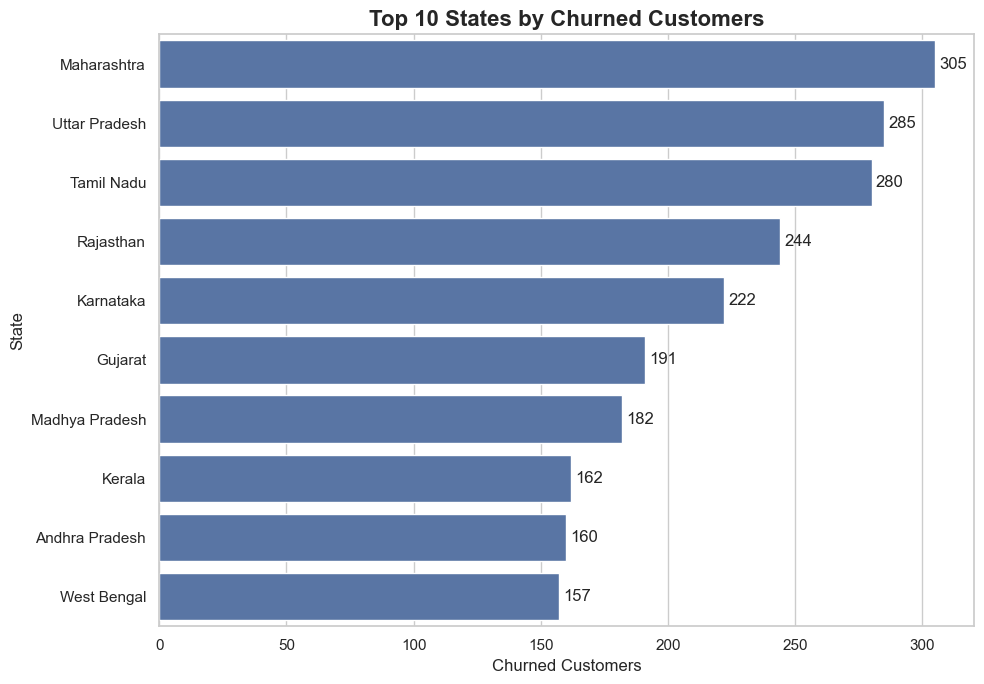

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=state_churn,
    x="churned_customers",
    y="state_name",
    ax=ax
)

ax.set_title(
    "Top 10 States by Churned Customers",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Churned Customers")
ax.set_ylabel("State")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "06_top10_states_circles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
#Circle / region table
circle_churn = (
    eda[eda["churn_flag"] == 1]
    .groupby("region_name")["customer_id"]
    .nunique()
    .reset_index(name="churned_customers")
    .sort_values(
        "churned_customers",
        ascending=False
    )
)

circle_churn

,region_name,churned_customers
1,North,992
2,South,956
0,East,841
3,West,717


### Observation

In [35]:
top_state = state_churn.iloc[0]

top_circle = circle_churn.iloc[0]

print(
    f"Observation: {top_state['state_name']} has the highest "
    f"number of churned customers among the top 10 states, "
    f"with {int(top_state['churned_customers']):,} churned customers."
)

print(
    f"At the regional/circle level, {top_circle['region_name']} "
    f"records the highest number of churned customers, with "
    f"{int(top_circle['churned_customers']):,} churned customers."
)

Observation: Maharashtra has the highest number of churned customers among the top 10 states, with 305 churned customers.
At the regional/circle level, North records the highest number of churned customers, with 992 churned customers.


### Average Data Usage by City Tier

In [36]:
tier_usage = (
    eda.groupby("city_tier", dropna=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_data_usage_gb=("avg_data_gb", "mean")
    )
    .reset_index()
)

tier_usage

,city_tier,customers,avg_data_usage_gb
0,Metro,4859,49.37
1,Tier-2,9211,41.70
2,Tier-3,4930,28.32


### Chart

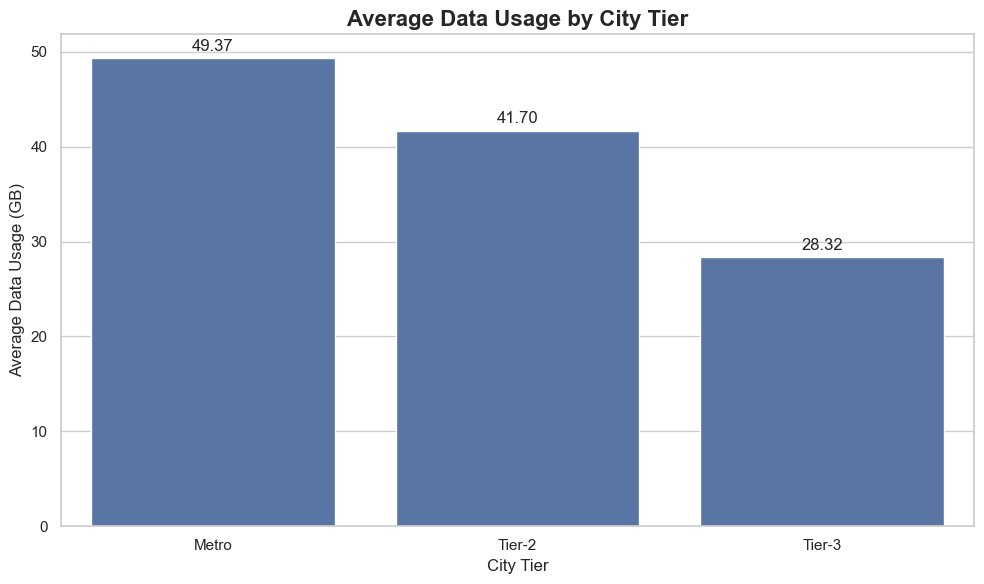

In [37]:
tier_order = [
    "Metro",
    "Tier-2",
    "Tier-3"
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tier_usage,
    x="city_tier",
    y="avg_data_usage_gb",
    order=tier_order,
    ax=ax
)

ax.set_title(
    "Average Data Usage by City Tier",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("City Tier")
ax.set_ylabel("Average Data Usage (GB)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "07_avg_data_usage_city_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

In [38]:
highest_usage = tier_usage.loc[
    tier_usage["avg_data_usage_gb"].idxmax()
]

lowest_usage = tier_usage.loc[
    tier_usage["avg_data_usage_gb"].idxmin()
]

print(
    f"Observation: {highest_usage['city_tier']} customers have "
    f"the highest average data usage at "
    f"{highest_usage['avg_data_usage_gb']:.2f} GB."
)

print(
    f"{lowest_usage['city_tier']} customers have the lowest "
    f"average usage at {lowest_usage['avg_data_usage_gb']:.2f} GB. "
    f"This highlights differences in data consumption across "
    f"city tiers."
)

Observation: Metro customers have the highest average data usage at 49.37 GB.
Tier-3 customers have the lowest average usage at 28.32 GB. This highlights differences in data consumption across city tiers.


### ARPU Distribution

In [39]:
arpu_data = eda[
    eda["monthly_charge"].notna()
].copy()

print(
    f"Customers with available monthly charge: "
    f"{len(arpu_data):,}"
)

print(
    f"Average monthly charge: "
    f"₹{arpu_data['monthly_charge'].mean():,.2f}"
)

print(
    f"Median monthly charge: "
    f"₹{arpu_data['monthly_charge'].median():,.2f}"
)

Customers with available monthly charge: 19,076
Average monthly charge: ₹819.42
Median monthly charge: ₹449.00


### Histogram

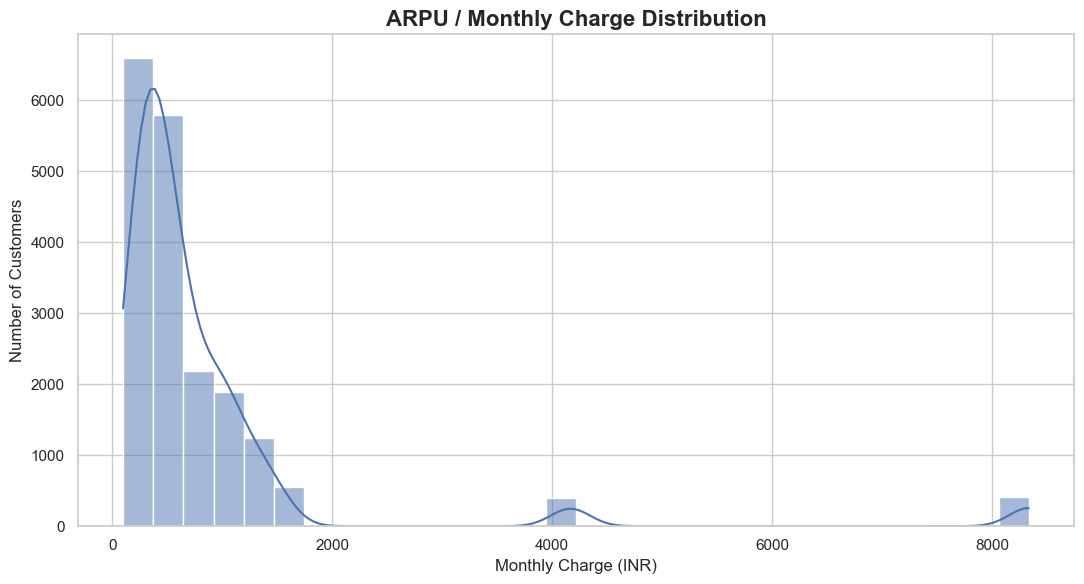

In [40]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=arpu_data,
    x="monthly_charge",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title(
    "ARPU / Monthly Charge Distribution",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Monthly Charge (INR)")
ax.set_ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "08_arpu_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

In [41]:
mean_arpu = arpu_data["monthly_charge"].mean()
median_arpu = arpu_data["monthly_charge"].median()

print(
    f"Observation: The average monthly charge across customers "
    f"with available plan information is ₹{mean_arpu:,.2f}, "
    f"while the median is ₹{median_arpu:,.2f}."
)

if mean_arpu > median_arpu:
    print(
        "The mean is higher than the median, indicating that "
        "higher-priced plans contribute to an upward-skewed "
        "monthly-charge distribution."
    )
else:
    print(
        "The mean and median are relatively close, indicating "
        "a more balanced monthly-charge distribution."
    )

Observation: The average monthly charge across customers with available plan information is ₹819.42, while the median is ₹449.00.
The mean is higher than the median, indicating that higher-priced plans contribute to an upward-skewed monthly-charge distribution.


### Network Quality vs Churn

In [42]:
network_churn = (
    eda.groupby("customer_status")
    .agg(
        customers=("customer_id", "nunique"),
        avg_dropped_call_rate=(
            "avg_dropped_call_rate",
            "mean"
        )
    )
    .reset_index()
)

network_churn

,customer_status,customers,avg_dropped_call_rate
0,Active,15494,2.36
1,Churned,3506,2.60


### Chart

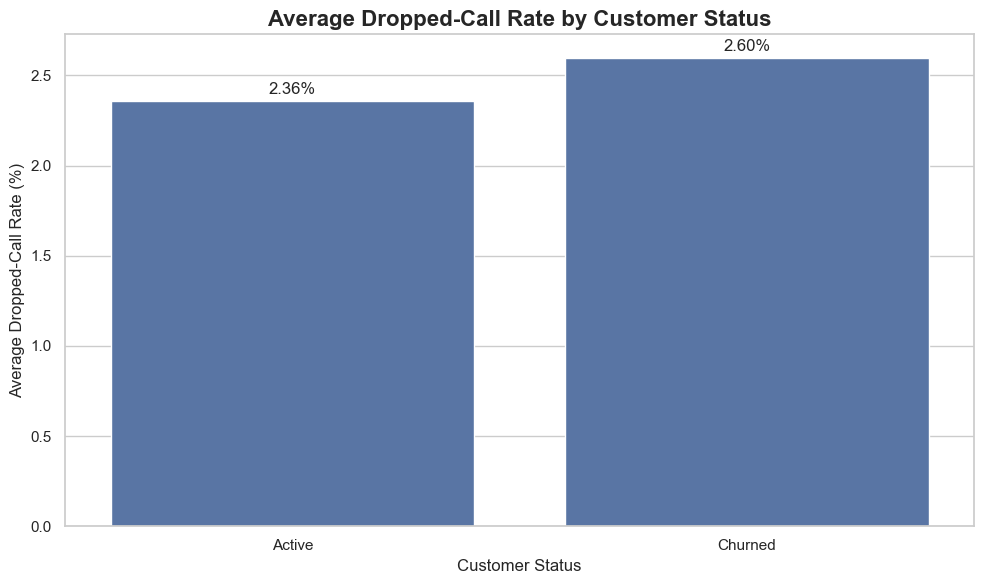

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=network_churn,
    x="customer_status",
    y="avg_dropped_call_rate",
    ax=ax
)

ax.set_title(
    "Average Dropped-Call Rate by Customer Status",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Average Dropped-Call Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    CHART_DIR / "09_network_quality_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

In [44]:
churned_network = network_churn[
    network_churn["customer_status"]
    .astype(str)
    .str.lower()
    == "churned"
]

active_network = network_churn[
    network_churn["customer_status"]
    .astype(str)
    .str.lower()
    == "active"
]

if not churned_network.empty and not active_network.empty:

    churned_drop = churned_network[
        "avg_dropped_call_rate"
    ].iloc[0]

    active_drop = active_network[
        "avg_dropped_call_rate"
    ].iloc[0]

    print(
        f"Observation: Churned customers have an average "
        f"dropped-call rate of {churned_drop:.2f}%, compared "
        f"with {active_drop:.2f}% among active customers."
    )

    if churned_drop > active_drop:
        print(
            "The higher dropped-call rate among churned customers "
            "suggests that poorer network experience may be "
            "associated with customer churn."
        )
    else:
        print(
            "The average dropped-call rate is not higher among "
            "churned customers, so this analysis does not show a "
            "positive relationship between dropped-call rate and churn."
        )

Observation: Churned customers have an average dropped-call rate of 2.60%, compared with 2.36% among active customers.
The higher dropped-call rate among churned customers suggests that poorer network experience may be associated with customer churn.


### Retention Campaign Outcomes

In [45]:
retention = retention_campaigns.copy()

retention["response"] = (
    retention["response"]
    .astype(str)
    .str.strip()
    .str.title()
)

retention["retained_flag"] = (
    retention["retained_flag"]
    .astype(str)
    .str.strip()
    .str.title()
)

response_order = [
    "Accepted",
    "Declined",
    "No Response"
]

retention_summary = (
    retention
    .groupby(
        ["response", "retained_flag"]
    )
    .size()
    .reset_index(name="customers")
)

retention_summary

,response,retained_flag,customers
0,Accepted,No,393
1,Accepted,Yes,2589
2,Declined,No,391
3,Declined,Yes,1486
4,No Response,No,354
5,No Response,Yes,1262


### Calculate retained percentage

In [46]:
retention_pivot = (
    retention_summary
    .pivot(
        index="response",
        columns="retained_flag",
        values="customers"
    )
    .fillna(0)
)

retention_pivot

retained_flag,No,Yes
response,,
Accepted,393,2589
Declined,391,1486
No Response,354,1262


### Chart

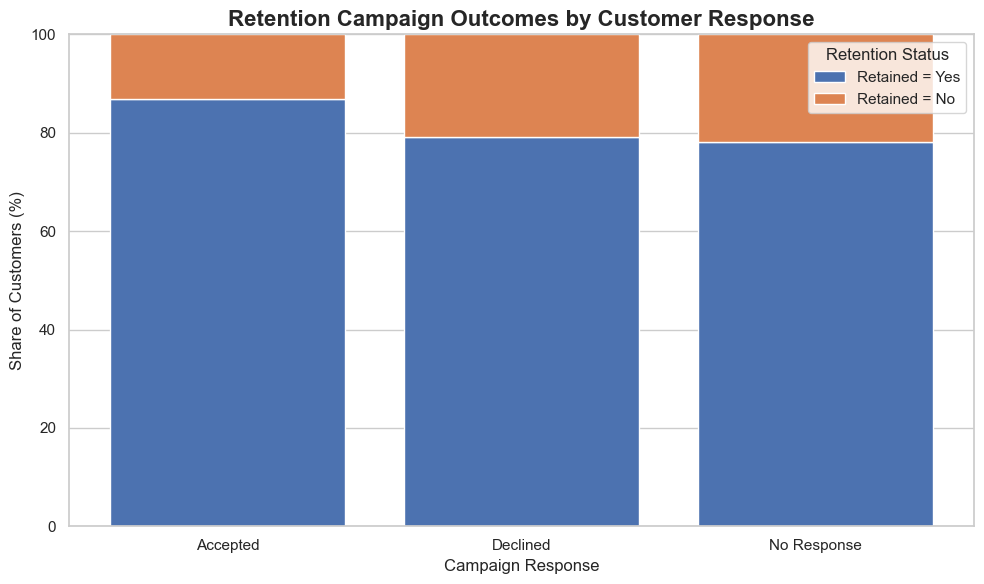

In [47]:
# Make sure the expected columns exist
for col in ["Yes", "No"]:
    if col not in retention_pivot.columns:
        retention_pivot[col] = 0

retention_pivot = retention_pivot.reindex(
    response_order,
    fill_value=0
)

retention_percentage = (
    retention_pivot
    .div(retention_pivot.sum(axis=1), axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(retention_percentage))

for retained_status in ["Yes", "No"]:

    values = retention_percentage[
        retained_status
    ].values

    ax.bar(
        retention_percentage.index,
        values,
        bottom=bottom,
        label=f"Retained = {retained_status}"
    )

    bottom += values

ax.set_title(
    "Retention Campaign Outcomes by Customer Response",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Campaign Response")
ax.set_ylabel("Share of Customers (%)")
ax.set_ylim(0, 100)

ax.legend(
    title="Retention Status"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "10_retention_campaign_outcomes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Calculate retained share

In [48]:
retention_rate = (
    retention
    .groupby("response")["retained_flag"]
    .apply(
        lambda x:
        (
            x.eq("Yes").sum()
            / len(x)
            * 100
        )
    )
    .reset_index(name="retained_share_pct")
)

retention_rate = retention_rate.sort_values(
    "retained_share_pct",
    ascending=False
)

retention_rate

,response,retained_share_pct
0,Accepted,86.82
1,Declined,79.17
2,No Response,78.09


### Observation

In [49]:
if not retention_rate.empty:

    highest_retention = retention_rate.iloc[0]

    print(
        f"Observation: The {highest_retention['response']} response "
        f"group has the highest retained share at "
        f"{highest_retention['retained_share_pct']:.2f}%."
    )

    print(
        "The comparison of accepted, declined, and no-response "
        "customers shows how campaign response behaviour is "
        "associated with subsequent customer retention."
    )

Observation: The Accepted response group has the highest retained share at 86.82%.
The comparison of accepted, declined, and no-response customers shows how campaign response behaviour is associated with subsequent customer retention.


### Verify all 10 charts

In [50]:
expected_charts = [
    "01_overall_churn.png",
    "02_churn_by_billing_cycle.png",
    "03_churn_by_tenure.png",
    "04_churn_by_unresolved_complaints.png",
    "05_churn_by_segment.png",
    "06_top10_states_circles.png",
    "07_avg_data_usage_city_tier.png",
    "08_arpu_distribution.png",
    "09_network_quality_vs_churn.png",
    "10_retention_campaign_outcomes.png"
]

print("Chart Verification")
print("=" * 50)

all_created = True

for chart in expected_charts:

    path = CHART_DIR / chart

    if path.exists():
        print(f"✓ {chart}")
    else:
        print(f"✗ {chart}")
        all_created = False

print("=" * 50)

if all_created:
    print("SUCCESS: All 10 required charts were created.")
else:
    print("ERROR: One or more charts are missing.")

Chart Verification
✓ 01_overall_churn.png
✓ 02_churn_by_billing_cycle.png
✓ 03_churn_by_tenure.png
✓ 04_churn_by_unresolved_complaints.png
✓ 05_churn_by_segment.png
✓ 06_top10_states_circles.png
✓ 07_avg_data_usage_city_tier.png
✓ 08_arpu_distribution.png
✓ 09_network_quality_vs_churn.png
✓ 10_retention_campaign_outcomes.png
SUCCESS: All 10 required charts were created.


### Create an EDA summary table

In [51]:
eda_summary = pd.DataFrame({
    "Analysis": [
        "Overall Churn",
        "Billing Cycle",
        "Tenure",
        "Unresolved Complaints",
        "Customer Segment",
        "State / Circle",
        "City Tier Data Usage",
        "ARPU Distribution",
        "Network Quality",
        "Retention Campaign"
    ],
    "Chart": [
        "Bar Chart",
        "Bar Chart",
        "Bar Chart",
        "Bar Chart",
        "Bar Chart",
        "Horizontal Bar",
        "Bar Chart",
        "Histogram",
        "Grouped Bar",
        "100% Stacked Bar"
    ],
    "Business Question": [
        "What is the overall churn level?",
        "Which billing cycle has higher churn?",
        "Which tenure group churns more?",
        "Does churn increase with unresolved complaints?",
        "Which customer segment has higher churn?",
        "Which locations have the most churned customers?",
        "How does data usage differ by city tier?",
        "How are monthly charges distributed?",
        "Is network quality associated with churn?",
        "How do campaign responses relate to retention?"
    ]
})

eda_summary

,Analysis,Chart,Business Question
0,Overall Churn,Bar Chart,What is the overall churn level?
1,Billing Cycle,Bar Chart,Which billing cycle has higher churn?
2,Tenure,Bar Chart,Which tenure group churns more?
3,Unresolved Complaints,Bar Chart,Does churn increase with unresolved complaints?
4,Customer Segment,Bar Chart,Which customer segment has higher churn?
5,State / Circle,Horizontal Bar,Which locations have the most churned customers?
6,City Tier Data Usage,Bar Chart,How does data usage differ by city tier?
7,ARPU Distribution,Histogram,How are monthly charges distributed?
8,Network Quality,Grouped Bar,Is network quality associated with churn?
9,Retention Campaign,100% Stacked Bar,How do campaign responses relate to retention?


### Final data-quality check

In [52]:
print("FINAL EDA VALIDATION")
print("=" * 60)

print(f"Customers in EDA table : {eda['customer_id'].nunique():,}")
print(f"EDA rows               : {len(eda):,}")
print(f"Duplicate customer IDs : {eda['customer_id'].duplicated().sum():,}")

print("\nMissing values in important analysis fields:")

important_fields = [
    "customer_status",
    "customer_segment",
    "tenure_months",
    "billing_cycle",
    "monthly_charge",
    "city_tier",
    "unresolved_complaints",
    "avg_data_gb",
    "avg_dropped_call_rate"
]

print(
    eda[important_fields]
    .isna()
    .sum()
)

print("=" * 60)

FINAL EDA VALIDATION
Customers in EDA table : 19,000
EDA rows               : 19,076
Duplicate customer IDs : 76

Missing values in important analysis fields:
customer_status          0
customer_segment         0
tenure_months            0
billing_cycle            0
monthly_charge           0
city_tier                0
unresolved_complaints    0
avg_data_gb              0
avg_dropped_call_rate    0
dtype: int64


### Final conclusion

### Phase 2 — EDA 

The exploratory analysis examined customer churn across billing cycle,
tenure, customer segment, unresolved complaints, geography, city tier,
monthly charges, network quality, and retention campaign outcomes.

The analysis provides a structured view of where churn is concentrated
and which customer or service characteristics are associated with higher
churn rates. These findings will be used as the analytical foundation
for Phase 3, where the key churn KPIs will be calculated and quantified.

All ten required EDA charts have been generated and exported as PNG
images for documentation and submission.